In [5]:
%tensorflow_version 2.1

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import math
from tensorflow.keras import layers

In [9]:
#Print versions
!python --versions
print('Numpy' + np.__version__)
print('Tensorflow ' + tf.__version__)

unknown option --versions
usage: python3 [option] ... [-c cmd | -m mod | file | -] [arg] ...
Try `python -h' for more information.
Numpy1.25.2
Tensorflow 2.15.0


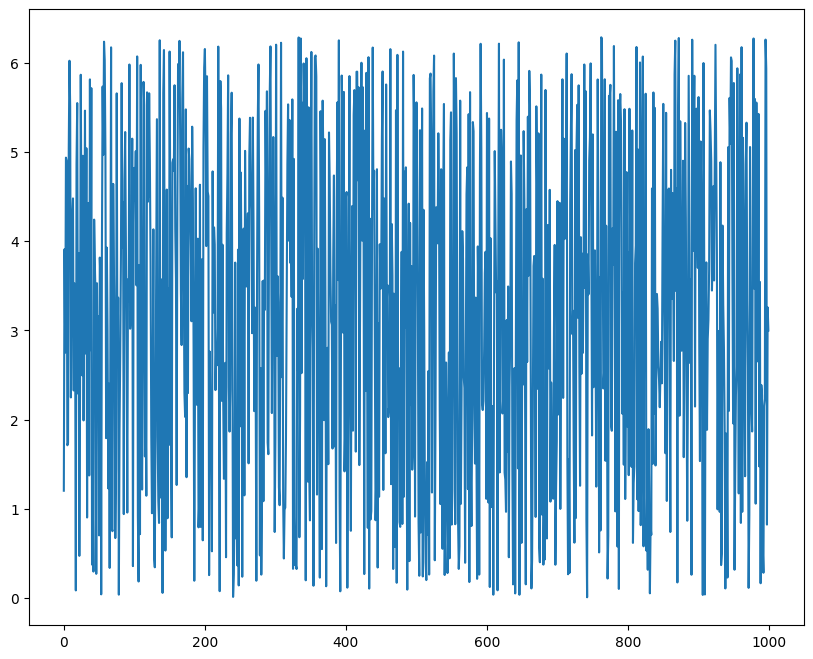

In [11]:
nsamples = 1000
val_ratio = 0.2
test_ratio = 0.2
tflite_model_name = 'sine_model'  # given .tflite suffix
c_model_name = 'sine_model'   # .h suffix


# Generate some random samples
np.random.seed(1234)
x_values = np.random.uniform(low=0, high=(2 * math.pi), size=nsamples)
plt.plot(x_values)

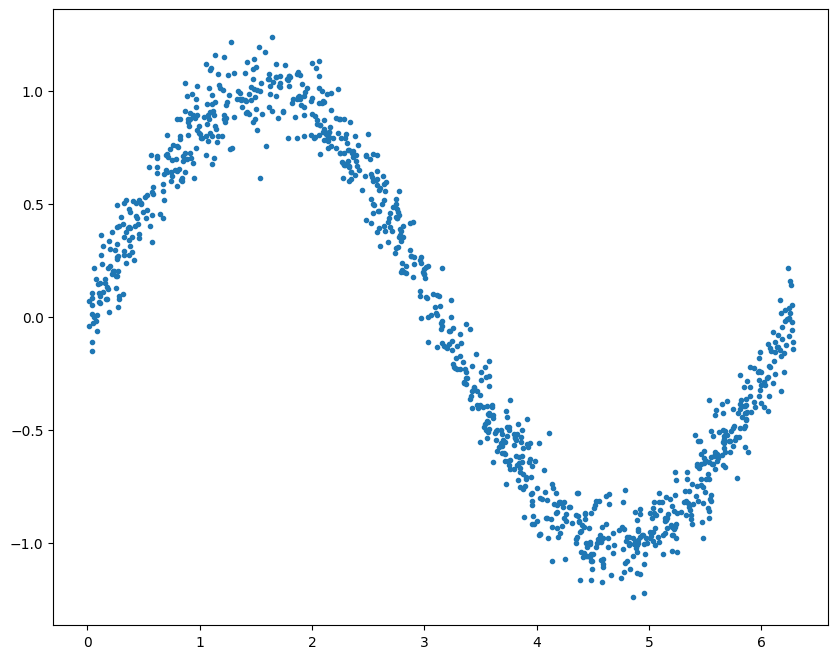

In [13]:
y_values = np.sin(x_values) + (0.1 * np.random.randn(x_values.shape[0]))
plt.plot(x_values, y_values, '.')

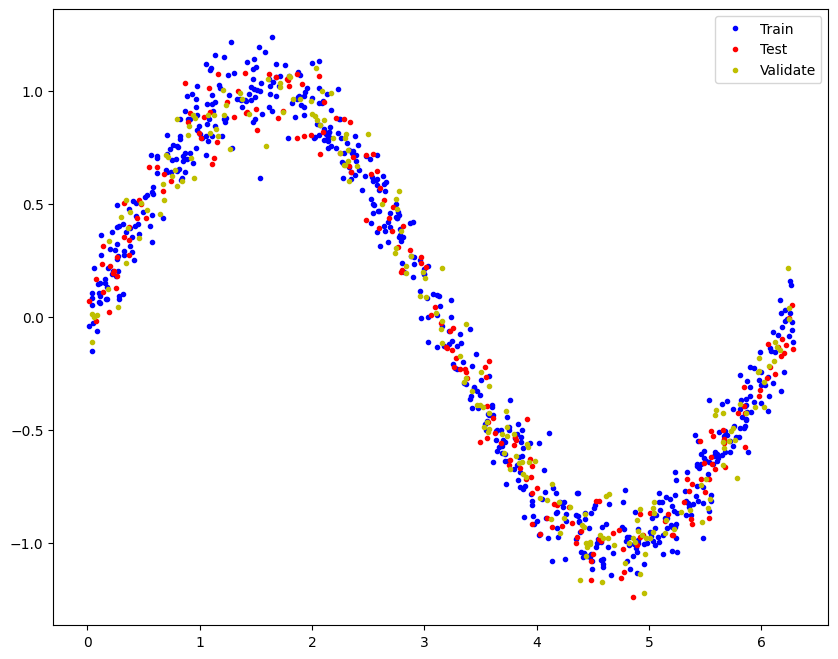

In [14]:
val_split = int(val_ratio * nsamples)
test_split = int(val_split + (test_ratio * nsamples))
x_val, x_test, x_train = np.split(x_values, [val_split, test_split])
y_val, y_test, y_train = np.split(y_values, [val_split, test_split])

assert(x_train.size + x_val.size + x_test.size) == nsamples

plt.plot(x_train, y_train, 'b.', label = "Train")
plt.plot(x_test, y_test, 'r.', label = "Test")
plt.plot(x_val, y_val, 'y.', label = "Validate")
plt.legend()
plt.show()

In [15]:
# Create a model
model = tf.keras.Sequential()
model.add(layers.Dense(16, activation = 'relu', input_shape = (1,)))
model.add(layers.Dense(16, activation = 'relu'))
model.add(layers.Dense(1))

In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                32        
                                                                 
 dense_1 (Dense)             (None, 16)                272       
                                                                 
 dense_2 (Dense)             (None, 1)                 17        
                                                                 
Total params: 321 (1.25 KB)
Trainable params: 321 (1.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [17]:
model.compile(optimizer='rmsprop', loss='mae', metrics=['mae'])

In [18]:
history = model.fit(x_train,
                    y_train,
                    epochs=500,
                    batch_size=100,
                    validation_data=(x_val, y_val))

Epoch 1/500
6/6 [==============================] - 2s 54ms/step - loss: 1.2719 - mae: 1.2719 - val_loss: 1.2585 - val_mae: 1.2585
Epoch 2/500
6/6 [==============================] - 0s 13ms/step - loss: 1.1309 - mae: 1.1309 - val_loss: 1.1421 - val_mae: 1.1421
Epoch 3/500
6/6 [==============================] - 0s 15ms/step - loss: 1.0353 - mae: 1.0353 - val_loss: 1.0414 - val_mae: 1.0414
Epoch 4/500
6/6 [==============================] - 0s 14ms/step - loss: 0.9534 - mae: 0.9534 - val_loss: 0.9539 - val_mae: 0.9539
Epoch 5/500
6/6 [==============================] - 0s 13ms/step - loss: 0.8873 - mae: 0.8873 - val_loss: 0.8803 - val_mae: 0.8803
Epoch 6/500
6/6 [==============================] - 0s 14ms/step - loss: 0.8287 - mae: 0.8287 - val_loss: 0.8111 - val_mae: 0.8111
Epoch 7/500
6/6 [==============================] - 0s 16ms/step - loss: 0.7696 - mae: 0.7696 - val_loss: 0.7357 - val_mae: 0.7357
Epoch 8/500
6/6 [==============================] - 0s 14ms/step - loss: 0.7137 - mae: 0.71

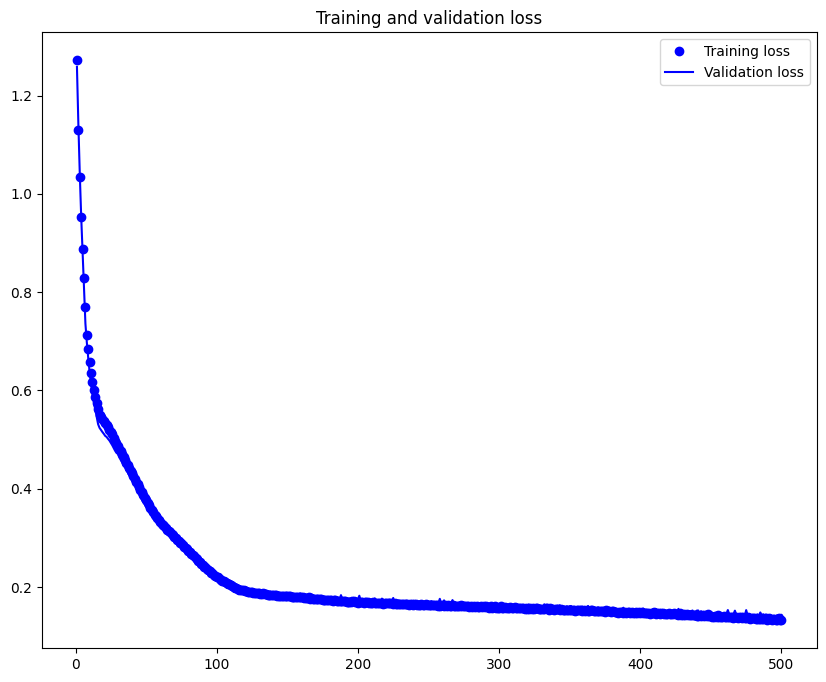

In [19]:
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

7/7 [==============================] - 0s 2ms/step


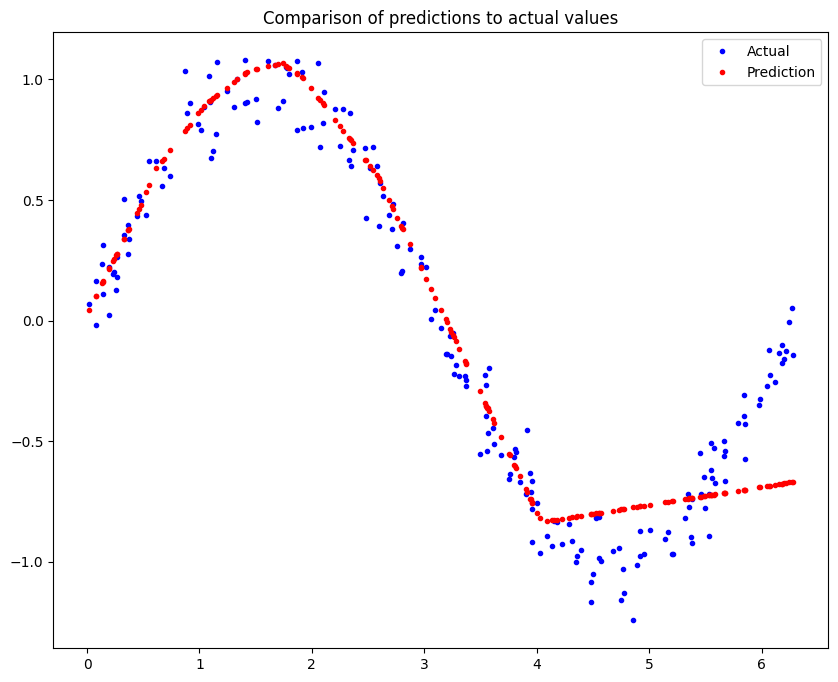

In [21]:
predictions = model.predict(x_test)

plt.clf()
plt.title("Comparison of predictions to actual values")
plt.plot(x_test, y_test, 'b.', label = 'Actual')
plt.plot(x_test, predictions, 'r.', label = 'Prediction')
plt.legend()
plt.show()

In [23]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.OPTIMIZE_FOR_SIZE]
tflite_model = converter.convert()

open(tflite_model_name + '.tflite', 'wb').write(tflite_model)

3168

In [ ]:
def hex_to_c_array(hex_data, var_name):
    c_str = ''
    c_str += '#ifndef' + var